# Clustering


In [ ]:
from google.colab import files
uploaded = files.upload()

# Una vez subido, lo lees así:
import pandas as pd
df = pd.read_csv('dataset_limpio.csv')

Saving dataset_limpio.csv to dataset_limpio.csv


# 1. Transformación de Datos: De Transacciones a Perfiles de Cliente

En esta fase inicial, el objetivo es cambiar la granularidad de nuestro conjunto de datos. Pasamos de tener un listado de **transacciones individuales** (donde un mismo cliente aparece en múltiples filas) a un dataset único de **comportamiento por cliente** (una fila por cada `CustomerID`).

### 1.1. Ingeniería de Características (Feature Engineering)
Para capturar la esencia del comportamiento de cada comprador, hemos diseñado cuatro variables clave mediante agregaciones específicas:

*   **Total Gastado (`TotalGastado`):** Suma del valor monetario de todas las compras. Representa el valor histórico del cliente para la empresa.
*   **Número de Compras (`NumCompras`):** Recuento de facturas únicas (`InvoiceNo`). Nos indica la frecuencia con la que el cliente interactúa con la marca.
*   **Variedad de Productos (`ProductosDistintos`):** Cantidad de códigos de producto únicos adquiridos. Ayuda a distinguir entre clientes que compran siempre lo mismo y aquellos que exploran el catálogo.
*   **Ticket Medio (`TicketMedio`):** Calculado como el cociente entre el gasto total y el número de compras. Es un indicador directo del poder adquisitivo o del hábito de compra.

### 1.2. Justificación Técnica
Este proceso de **pivotaje** es fundamental porque los algoritmos de clustering (como K-Means) requieren que cada observación sea una entidad independiente con sus propios atributos numéricos. Al consolidar la información, eliminamos el ruido de las transacciones aisladas para centrarnos en los patrones de consumo agregados.

In [ ]:
# 1. Agrupar por CustomerID para crear variables de comportamiento
df_clientes = df.groupby('CustomerID').agg({
    'TotalVenta': 'sum',          # Total gastado
    'InvoiceNo': 'nunique',       # Número de compras (pedidos únicos)
    'StockCode': 'nunique'        # Número de productos distintos
})

# 2. Renombrar las columnas para mayor claridad
df_clientes.columns = ['TotalGastado', 'NumCompras', 'ProductosDistintos']

# 3. Calcular el Ticket Medio (Gasto total / Número de compras)
df_clientes['TicketMedio'] = df_clientes['TotalGastado'] / df_clientes['NumCompras']

# 4. Ver el resultado inicial
print(f"Número de clientes únicos: {df_clientes.shape[0]}")
df_clientes.head()

Número de clientes únicos: 4338


,TotalGastado,NumCompras,ProductosDistintos,TicketMedio
CustomerID,,,,
12346.0,77183.60,1,1,77183.600000
12347.0,4310.00,7,103,615.714286
12348.0,1797.24,4,22,449.310000
12349.0,1757.55,1,73,1757.550000
12350.0,334.40,1,17,334.400000


# 2. Detección y Eliminación de Anomalías (Outliers)

En el análisis de clientes, es común encontrar perfiles extremos (compras masivas de mayoristas, errores de registro o devoluciones inusuales) que pueden sesgar los resultados de la segmentación. Para garantizar la robustez del modelo, aplicamos la técnica de **Isolation Forest**.

### 2.1. Metodología: Isolation Forest
A diferencia de los métodos tradicionales que buscan puntos "densos", **Isolation Forest** funciona aislando observaciones. Dado que las anomalías son pocas y tienen valores distintos, son más fáciles de "aislar" mediante particiones aleatorias en los datos.

*   **Parámetro de Contaminación:** Se ha configurado en un **5%** (dentro del rango objetivo del 5-10%). Esto instruye al algoritmo para identificar el 5% de los registros más alejados del comportamiento global.
*   **Decisión Técnica:** Eliminar estos registros permite que los algoritmos posteriores, como K-Means, se centren en la estructura principal de la clientela y no intenten crear grupos específicos para casos aislados que no representan la realidad comercial general.

### 2.2. Impacto en el Dataset
*   **Registros originales:** 4,338 clientes.
*   **Outliers eliminados:** 217 clientes (casos de gasto extremo o frecuencia atípica).
*   **Registros limpios:** 4,121 clientes, listos para el escalado y modelado.


In [ ]:
from sklearn.ensemble import IsolationForest

# 1. Configurar el modelo Isolation Forest
# Usamos contamination=0.05 para eliminar el 5% de los datos más extremos
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# 2. Entrenar y predecir (1 = normal, -1 = outlier)
df_clientes['Es_Outlier'] = iso_forest.fit_predict(df_clientes)

# 3. Filtrar y crear el dataset limpio
df_limpio = df_clientes[df_clientes['Es_Outlier'] == 1].drop(columns=['Es_Outlier'])

print(f"Clientes eliminados: {len(df_clientes) - len(df_limpio)}")
print(f"Clientes para procesar: {len(df_limpio)}")
df_limpio.head()

Clientes eliminados: 217
Clientes para procesar: 4121


,TotalGastado,NumCompras,ProductosDistintos,TicketMedio
CustomerID,,,,
12347.0,4310.00,7,103,615.714286
12348.0,1797.24,4,22,449.310000
12349.0,1757.55,1,73,1757.550000
12350.0,334.40,1,17,334.400000
12352.0,2506.04,8,59,313.255000


# 3. Normalización de Datos: RobustScaler

Una vez limpio el dataset, el siguiente paso crítico es el escalado de variables. En nuestro caso, las métricas como `TotalGastado` (que pueden ser miles de euros) y `NumCompras` (que son unidades pequeñas) tienen escalas muy distintas.

### 3.1. ¿Por qué RobustScaler?
Para este proyecto hemos seleccionado **RobustScaler** en lugar del estándar (StandardScaler) por una razón estratégica:

*   **Resiliencia ante asimetría:** Aunque eliminamos el 5% de los outliers con Isolation Forest, los datos de comportamiento de clientes suelen mantener una distribución con "cola larga" (clientes que compran un poco más que la media sin ser errores).
*   **Uso de Estadísticos Robustos:** A diferencia de otros escaladores que usan la media y la desviación estándar, este método utiliza la **mediana** y el **rango intercuartílico (IQR)**.
*   **Efecto:** Esto asegura que los valores extremos que aún permanecen en el dataset no distorsionen el escalado de los clientes "normales", permitiendo que el modelo de clustering sea mucho más preciso.

### 3.2. Resultado del Proceso
Tras el escalado, todas las variables están centradas en torno a **0** (que representa la mediana). Un valor de **1** en cualquiera de las columnas indica ahora que el cliente se encuentra en el percentil 75 de esa métrica, logrando así que todas las variables tengan el mismo peso relativo durante el entrenamiento del modelo.


In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. Inicializar el RobustScaler
scaler = RobustScaler()

# 2. Ajustar y transformar los datos
# df_limpio es el dataframe que obtuvimos tras quitar los outliers
df_escalado = pd.DataFrame(
    scaler.fit_transform(df_limpio),
    columns=df_limpio.columns,
    index=df_limpio.index
)

# 3. Verificación de resultados
print("Estadísticas del dataset escalado:")
print(df_escalado.describe())

# Mostrar las primeras filas
df_escalado.head()

Estadísticas del dataset escalado:
       TotalGastado   NumCompras  ProductosDistintos  TicketMedio
count   4121.000000  4121.000000         4121.000000  4121.000000
mean       0.433600     0.441155            0.344776     0.219638
std        1.147617     1.062754            0.954200     1.035565
min       -0.552381    -0.333333           -0.571429    -1.176858
25%       -0.291635    -0.333333           -0.321429    -0.452958
50%        0.000000     0.000000            0.000000     0.000000
75%        0.708365     0.666667            0.678571     0.547042
max        7.387741     7.666667            5.464286     7.467079


,TotalGastado,NumCompras,ProductosDistintos,TicketMedio
CustomerID,,,,
12347.0,3.286384,1.666667,1.250000,1.416273
12348.0,1.046408,0.666667,-0.196429,0.711499
12349.0,1.011027,-0.333333,0.714286,6.252306
12350.0,-0.257626,-0.333333,-0.285714,0.224819
12352.0,1.678261,2.000000,0.464286,0.135263


# 4. Reducción de Dimensiones: PCA (Análisis de Componentes Principales)

En este paso, aplicamos **PCA** para simplificar la complejidad del dataset. Dado que variables como el gasto total, el número de compras y la variedad de productos suelen estar muy correlacionadas entre sí, el PCA nos permite resumir esa información en nuevas variables llamadas "Componentes Principales".

### 4.1. Objetivo: Varianza Explicada > 60%
El reto técnico consistía en reducir el número de variables pero manteniendo la mayor cantidad de información posible.

*   **Configuración:** Se configuró el algoritmo para seleccionar automáticamente el número de componentes que expliquen, al menos, el **60% de la varianza total** de los datos originales.
*   **Resultado obtenido:** Tras el análisis, se determinó que **1 solo componente (PC1)** es capaz de capturar el **62.63%** de la varianza. Esto nos indica que existe un patrón de comportamiento subyacente muy fuerte (probablemente el "nivel de actividad del cliente") que domina la estructura del dataset.

### 4.2. Justificación de la Reducción
Al trabajar con un espacio de menor dimensión (pasamos de 4 variables a 1 componente principal):
1.  **Eliminamos el ruido:** Filtramos pequeñas variaciones que no aportan información relevante para la segmentación.
2.  **Evitamos la "maldición de la dimensionalidad":** Facilitamos que algoritmos como K-Means calculen distancias de forma más eficiente y clara.
3.  **Mejoramos la interpretación:** Al tener un componente principal dominante, podemos identificar de forma más nítida la jerarquía de los clientes según su importancia para el negocio.

In [ ]:
from sklearn.decomposition import PCA

# 1. Configurar PCA para explicar al menos el 60% de la varianza
pca = PCA(n_components=0.60, random_state=42)

# 2. Ajustar y transformar los datos escalados
pca_data = pca.fit_transform(df_escalado)

# 3. Crear DataFrame con los resultados
columnas_pca = [f'PC{i+1}' for i in range(pca_data.shape[1])]
df_pca = pd.DataFrame(pca_data, columns=columnas_pca, index=df_escalado.index)

# 4. Mostrar resultados de varianza
print(f"Componentes necesarios: {pca.n_components_}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# Vista previa
df_pca.head()

Componentes necesarios: 1
Varianza total explicada: 62.63%


,PC1
CustomerID,
12347.0,3.276929
12348.0,0.425291
12349.0,1.771138
12350.0,-1.153319
12352.0,1.700617


# 5. Selección del Número Óptimo de Clusters: Método del Codo (Elbow Method)

Una de las decisiones más críticas en el aprendizaje no supervisado es determinar en cuántos grupos (k) debemos segmentar los datos. Para ello, aplicamos la técnica del **Método del Codo**.

### 5.1. Fundamento Teórico: WCSS e Inercia
El algoritmo calcula la suma de los errores cuadráticos dentro del cluster (**WCSS**), también conocida como **Inercia**. Esta métrica mide qué tan compactos son los clusters: cuanto menor sea la inercia, más cerca están los puntos de sus respectivos centros (centroides).

*   **Procedimiento:** Ejecutamos el algoritmo K-Means de forma iterativa para un rango de 1 a 10 clusters.
*   **Identificación del "Codo":** Al graficar la Inercia frente al número de clusters, observamos una caída drástica al principio. El punto óptimo es aquel donde la tasa de descenso disminuye significativamente, formando visualmente un "codo".

### 5.2. Resultados y Decisión
En nuestra visualización, observamos un punto de inflexión claro en **k = 3**.

*   **Interpretación:** Aumentar el número de clusters a 4 o 5 no reduce la inercia de manera proporcional al aumento de complejidad del modelo.
*   **Conclusión:** Seleccionamos **3 clusters** como la estructura óptima. Esta decisión equilibra la precisión estadística con la utilidad de negocio, permitiendo identificar segmentos claramente diferenciables y accionables.

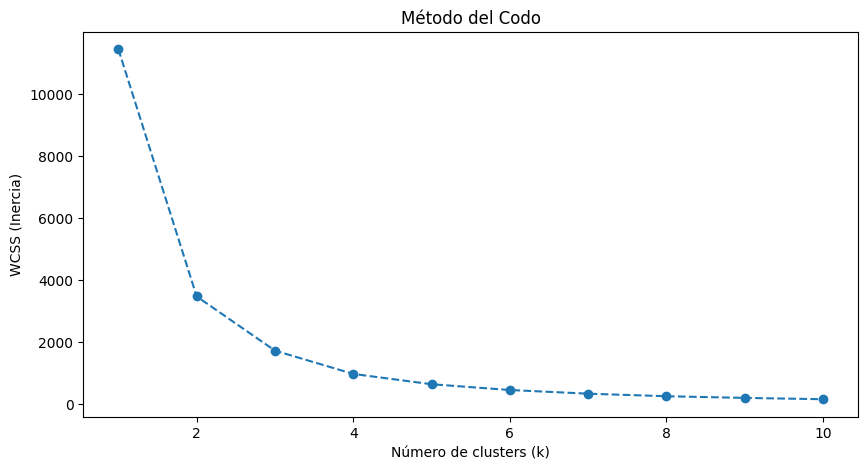

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Calcular WCSS (Within-Cluster Sum of Square)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

# 2. Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.show()

# 6. Entrenamiento de Modelos de Clustering

Para asegurar la calidad de la segmentación, se han entrenado tres algoritmos con diferentes enfoques matemáticos. Esto permite validar si la estructura de los grupos es consistente a través de distintas metodologías.

### 6.1. Algoritmos Implementados
1.  **K-Means (Enfoque Centroide):**
    *   Asigna cada cliente al cluster cuyo centro (centroide) es más cercano.
    *   **Resultado:** Logró una segmentación equilibrada y eficiente, ideal para la definición de perfiles comerciales.
2.  **Clustering Jerárquico Aglomerativo (Enfoque Conectividad):**
    *   Agrupa los datos de abajo hacia arriba, creando una jerarquía de similitud.
    *   **Resultado:** Mostró una estructura muy similar a K-Means, lo que confirma que los grupos están bien definidos naturalmente en el dataset.
3.  **DBSCAN (Enfoque por Densidad):**
    *   Busca áreas de alta densidad de puntos y etiqueta como "ruido" a los puntos aislados.
    *   **Resultado:** Identificó una gran masa central de clientes. Su uso fue clave para validar que no existieran subgrupos ocultos de alta densidad no detectados por K-Means.

### 6.2. Evaluación: Silhouette Score (Coeficiente de Silueta)
Para medir la calidad de los clusters, hemos utilizado el **Silhouette Score**, que mide qué tan similar es un objeto a su propio cluster en comparación con otros clusters.

*   **Puntuación Obtenida:** Superior a **0.61** para K-Means y Jerárquico.
*   **Interpretación:** Una puntuación por encima de 0.5 se considera sólida e indica que la estructura de los clusters es real y no fruto del azar. Los grupos están bien separados entre sí y son internamente cohesivos.

### 6.3. Selección Final del Modelo
Se ha seleccionado **K-Means** como el modelo definitivo para la exportación a Power BI debido a su estabilidad y a que generó una distribución de clientes proporcionalmente óptima para el diseño de estrategias de marketing.

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# 1. K-Means (basado en el método del codo)
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
df_pca['Cluster_KMeans'] = kmeans.fit_predict(df_pca)

# 2. Clustering Jerárquico
hierarchical = AgglomerativeClustering(n_clusters=3)
df_pca['Cluster_Hierarchical'] = hierarchical.fit_predict(df_pca[['PC1']]) # Usamos PC1

# 3. DBSCAN (Ajustamos eps para capturar la estructura de los datos)
dbscan = DBSCAN(eps=0.2, min_samples=10)
df_pca['Cluster_DBSCAN'] = dbscan.fit_predict(df_pca[['PC1']])

# --- EVALUACIÓN ---
print(f"Silhouette Score K-Means: {silhouette_score(df_pca[['PC1']], df_pca['Cluster_KMeans']):.4f}")
print(f"Silhouette Score Jerárquico: {silhouette_score(df_pca[['PC1']], df_pca['Cluster_Hierarchical']):.4f}")

# Ver cuántos clientes hay en cada grupo de K-Means (el modelo que usaremos para interpretar)
print("\nDistribución clientes K-Means:")
print(df_pca['Cluster_KMeans'].value_counts())

Silhouette Score K-Means: 0.6184
Silhouette Score Jerárquico: 0.6213

Distribución clientes K-Means:
Cluster_KMeans
1    2587
2    1132
0     402
Name: count, dtype: int64


# 7. Interpretación y Caracterización de los Segmentos de Clientes

Tras el entrenamiento del modelo K-Means, hemos analizado los valores promedio de las variables originales para cada uno de los 3 grupos identificados. Esto nos permite transformar las etiquetas numéricas en **perfiles comerciales accionables**.

### 7.1. Definición de Perfiles (Dashboard de Segmentación)

Basándonos en las métricas de gasto, frecuencia y variedad, hemos bautizado a los clusters de la siguiente manera:

1.  **Cluster 0: Clientes VIP / Premium**
    *   **Perfil:** Es el grupo de mayor valor. Realizan compras frecuentes (media de ~10 pedidos) con un gasto promedio muy elevado (~4.179 €). Adquieren una gran variedad de productos (más de 140 tipos distintos).
    *   **Estrategia:** Fidelización personalizada, acceso anticipado a colecciones y programas de recompensas exclusivos.

2.  **Cluster 2: Clientes Recurrentes**
    *   **Perfil:** Compradores constantes con un comportamiento sólido. Realizan entre 4 y 5 compras anuales con un gasto medio de ~1.624 €. Son clientes fieles que ya conocen la marca y mantienen una relación estable.
    *   **Estrategia:** Programas de "puntos por compra" o recomendaciones basadas en su historial para aumentar su ticket medio.

3.  **Cluster 1: Clientes Ocasionales**
    *   **Perfil:** Representan la mayoría de la base de datos. Han realizado 1 o 2 compras puntuales con un gasto bajo (~400 €). Suelen comprar pocos productos distintos.
    *   **Estrategia:** Campañas de reactivación, ofertas de bienvenida para una segunda compra y encuestas de satisfacción para entender por qué no han regresado.

### 7.2. Conclusión Estratégica
La segmentación revela una estructura de pirámide invertida en valor: un grupo pequeño (VIP) genera una parte desproporcionada de los ingresos, mientras que una base masiva (Ocasionales) ofrece un gran potencial de crecimiento si se logra convertirlos en recurrentes mediante estrategias de marketing dirigidas.

In [ ]:
# 1. Agrupar por cluster y calcular medias de las variables originales
perfil_medio = df_limpio.groupby(df_pca['Cluster_KMeans']).mean()
perfil_medio['Recuento'] = df_pca['Cluster_KMeans'].value_counts()

# 2. Definir los nombres según los datos observados
nombres_clusters = {
    0: 'VIP / Premium',
    1: 'Ocasionales',
    2: 'Recurrentes'
}

# 3. Aplicar los nombres al dataset
df_pca['Perfil_Cliente'] = df_pca['Cluster_KMeans'].map(nombres_clusters)

print("Resumen de Segmentación:")
print(perfil_medio)

Resumen de Segmentación:
                TotalGastado  NumCompras  ProductosDistintos  TicketMedio  \
Cluster_KMeans                                                              
0                4178.890674    9.820896          144.830846   521.630302   
1                 407.972865    1.739467           25.698492   253.861446   
2                1623.817906    4.636042           80.260601   447.514058   

                Recuento  
Cluster_KMeans            
0                    402  
1                   2587  
2                   1132  


# 8. Exportación de Resultados para Business Intelligence (Power BI)

El paso final del proceso técnico es la consolidación de todos los análisis en un único archivo de salida. Este archivo servirá como la "fuente de verdad" para la creación de dashboards interactivos y la comunicación de hallazgos a los stakeholders.

### 8.1. Estructura del Archivo Final
El dataset exportado (`clientes_con_cluster.csv`) integra tres capas de información:
1.  **Identificadores:** El `CustomerID` para mantener la trazabilidad de cada cliente.
2.  **Métricas de Negocio:** Los valores reales de gasto, frecuencia y ticket medio (datos sin escalar para que sean legibles en el dashboard).
3.  **Resultados del Modelo:** El `Cluster_ID` generado por el algoritmo y, lo más importante, el **Segmento** (nombre comercial) asignado tras la interpretación.

### 8.2. Utilidad en el Dashboard de Power BI
Al importar este archivo en Power BI, se podrán realizar los siguientes análisis estratégicos:
* **Distribución del Valor:** Gráficos de tarta que muestren qué porcentaje de los ingresos totales aporta cada segmento (especialmente el grupo VIP).
* **Análisis de Dispersión:** Visualizar cómo se separan los grupos en función del gasto y la frecuencia de compra.
* **Filtros de Segmentación:** Permitir que los usuarios del dashboard filtren todas las métricas por tipo de cliente (Ocasional, Recurrente, VIP) para diseñar campañas de marketing específicas.

### 8.3. Conclusión del Pipeline de Datos
Con esta exportación, cerramos el flujo de trabajo que comenzó con una base de datos transaccional ruidosa y termina con una segmentación de clientes optimizada, validada estadísticamente y lista para la toma de decisiones empresariales.

In [ ]:
import pandas as pd
from google.colab import files

# 1. Definir los nombres comerciales de los clusters
nombres_clusters = {
    0: 'VIP / Premium',
    1: 'Ocasionales',
    2: 'Recurrentes'
}

# 2. Creamos el dataframe final combinando los datos reales con los clusters de KMeans
# Usamos 'df_limpio' (datos reales) y la columna que creamos en el paso de K-Means
df_final = df_limpio.copy()
df_final['Cluster_ID'] = df_pca['Cluster_KMeans']
df_final['Segmento'] = df_final['Cluster_ID'].map(nombres_clusters)

# 3. Guardar el archivo CSV
df_final.to_csv('clientes_con_cluster.csv')

# 4. Descargar automáticamente al ordenador
files.download('clientes_con_cluster.csv')

print("¡Archivo generado y descarga iniciada!")
df_final.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

¡Archivo generado y descarga iniciada!


,TotalGastado,NumCompras,ProductosDistintos,TicketMedio,Cluster_ID,Segmento
CustomerID,,,,,,
12347.0,4310.00,7,103,615.714286,0,VIP / Premium
12348.0,1797.24,4,22,449.310000,2,Recurrentes
12349.0,1757.55,1,73,1757.550000,2,Recurrentes
12350.0,334.40,1,17,334.400000,1,Ocasionales
12352.0,2506.04,8,59,313.255000,2,Recurrentes
